En el presente notebook se busca reordenar y dejar comentado el programa de calculo preedictivo de concentracion de deuterio en Tp de Embalse (RJDIM)

En el nootbook a continuación se generan los diccionarios donde cada uno contiene la información necesaria para realizar el calculo en cada uno

In [105]:
def canales_por_rango(fila: str, col_ini: int, col_fin: int):
    return [f"{fila}-{c:02d}" for c in range(col_ini, col_fin + 1)]

rangos = {
    "A": [(9, 14)],
    "B": [(6, 17)],
    "C": [(5, 18)],
    "D": [(4, 19)],
    "E": [(3, 20)],
    "F": [(3, 20)],
    "G": [(2, 21)],
    "H": [(2, 21)],
    "J": [(1, 22)],
    "K": [(1, 22)],
    "L": [(1, 22)],
    "M": [(1, 22)],
    "N": [(1, 22)],
    "O": [(1, 22)],
    "P": [(2, 21)],
    "Q": [(2, 21)],
    "R": [(3, 20)],
    "S": [(3, 20)],
    "T": [(4, 19)],
    "U": [(5, 18)],
    "V": [(6, 17)],
    "W": [(9, 14)],
}

canales = []
for fila, lista_rangos in rangos.items():
    for ini, fin in lista_rangos:
        canales.extend(canales_por_rango(fila, ini, fin))

canales_dict = {
    ch: {
        "masa_g": 444.7,
        "H": 5,  # ug/g -Initial hydrogen concentration
        "T_°C": [],
        "LT_m": [],
        "flujo": [],
        "Lf_m": [],
        "a_i": None,
        "b_i": None,
        "a_o": None,
        "b_o": None,
    }
    for ch in canales
}

print("test")

test


Declaro curvas de flujo y temperatura para cada canal

In [106]:
# TEMPERATURA


from pathlib import Path
import pandas as pd
import re

TEMP_DIR = Path(r".\data\pressure&temperature\canales_BOL")

def _norm(s: str) -> str:
    # normaliza nombres para matchear "°C", "ºC", espacios, etc.
    s = s.lower().replace("°", "o").replace("º", "o")
    return re.sub(r"[^a-z0-9]+", "", s)

def _find_length_col(df: pd.DataFrame):
    for c in df.columns:
        n = _norm(str(c))
        if n in ("lengthm", "distancem", "axiallocationm", "positionm"):
            return c
        if ("length" in n or "distance" in n or "axial" in n or "position" in n) and n.endswith("m"):
            return c
    return None

def _find_temp_col(df: pd.DataFrame):
    for c in df.columns:
        n = _norm(str(c))
        # "temperatureoc" o "tempoc"
        if (n.startswith("temperature") or n.startswith("temp")) and n.endswith("oc"):
            return c
        if "temperature" in n and "oc" in n:
            return c
    return None

def _leer_archivo_pt_tabular(path: Path) -> pd.DataFrame:
    # En tu ejemplo, el .pt es tab-separado
    try:
        return pd.read_csv(path, sep="\t", encoding="utf-8")
    except Exception:
        # fallback por si el separador cambia
        return pd.read_csv(path, sep=None, engine="python", encoding="utf-8")

def cargar_L_y_T_en_diccionario(canales, canales_dict, base_dir=TEMP_DIR):
    faltantes = []
    sin_cols = []

    for ch in canales:
        stem = ch.replace("-", "")  # "R-09" -> "R09"
        candidatos = [
            base_dir / f"{stem}.pt",
            base_dir / f"{ch}.pt",
            base_dir / f"{stem}.tsv",
            base_dir / f"{ch}.tsv",
            base_dir / f"{stem}.txt",
            base_dir / f"{ch}.txt",
            base_dir / f"{stem}.csv",
            base_dir / f"{ch}.csv",
        ]

        path = next((p for p in candidatos if p.exists()), None)
        if path is None:
            faltantes.append(ch)
            continue

        df = _leer_archivo_pt_tabular(path)

        col_L = _find_length_col(df)
        col_T = _find_temp_col(df)

        if col_L is None or col_T is None:
            sin_cols.append((ch, path.name, list(df.columns)))
            continue

        tmp = df[[col_L, col_T]].apply(pd.to_numeric, errors="coerce").dropna()

        canales_dict[ch]["LT_m"]  = tmp[col_L].tolist()   # Length(m)
        canales_dict[ch]["T_°C"] = tmp[col_T].tolist()   # Temperature (°C)

    return faltantes, sin_cols, canales_dict

# --- uso ---
# asumimos que ya tenés: canales (lista) y canales_dict (dict)
faltantes, sin_cols, canales_dict = cargar_L_y_T_en_diccionario(canales, canales_dict)

print(f"OK: {len(canales_dict) - len(faltantes) - len(sin_cols)} canales cargados con L_m y T_°C")
if faltantes:
    print("Faltan archivos para:", faltantes[:10], "...")  # muestra algunos
if sin_cols:
    print("Archivos leídos pero no pude detectar columnas en (primeros 3):")
    for item in sin_cols[:3]:
        print(item)


#FLUJO

FLUX_DIR = Path(r"C:\Users\jkortsarz\Downloads\RJDIM\data\flux\calandria_tubes_extended")

def _leer_flux_2cols(path: Path) -> pd.DataFrame:
    """
    Lee archivo de flujo con 2 columnas:
      col0 = Lf_m
      col1 = flujo
    Soporta separador por tabs/espacios y con/sin header.
    """
    # intento robusto: whitespace/tab, sin header
    try:
        df = pd.read_csv(path, sep=r"\s+|\t+", engine="python", header=None, comment="#")
    except Exception:
        df = pd.read_csv(path, sep=None, engine="python", header=None, comment="#")

    # Si vino con más columnas por algún motivo, me quedo con las primeras 2
    df = df.iloc[:, :2].copy()
    df.columns = ["Lf_m", "flujo"]

    # numérico + limpiar NaN
    df["Lf_m"] = pd.to_numeric(df["Lf_m"], errors="coerce")
    df["flujo"] = pd.to_numeric(df["flujo"], errors="coerce")
    df = df.dropna()

    return df

def cargar_flux_en_diccionario(canales, canales_dict, flux_dir=FLUX_DIR, factor_L=6.0):
    faltantes = []
    problemas = []

    for ch in canales:
        stem = ch.replace("-", "")  # "O-17" -> "O17"

        candidatos = [
            flux_dir / f"{stem}.flx",
            flux_dir / f"{ch}.flx",
            flux_dir / f"{stem}.txt",
            flux_dir / f"{ch}.txt",
            flux_dir / f"{stem}.csv",
            flux_dir / f"{ch}.csv",
            flux_dir / f"{stem}.tsv",
            flux_dir / f"{ch}.tsv",
        ]

        path = next((p for p in candidatos if p.exists()), None)
        if path is None:
            faltantes.append(ch)
            continue

        try:
            df = _leer_flux_2cols(path)

            # guardar como listas
            canales_dict[ch]["Lf_m"] = (df["Lf_m"] * factor_L).tolist()
            canales_dict[ch]["flujo"]  = df["flujo"].tolist()

        except Exception as e:
            problemas.append((ch, path.name, str(e)))

    return faltantes, problemas

# --- uso ---
# si ya tenés `canales` y `canales_dict`:
faltantes, problemas = cargar_flux_en_diccionario(canales, canales_dict)

print("Faltan archivos:", len(faltantes))
print("Problemas al leer:", len(problemas))


OK: 380 canales cargados con L_m y T_°C
Faltan archivos: 0
Problemas al leer: 0


Se hace un fitting con los datos masa de Deuterio en solucion solida de mediciones en tubos de presión de otras plantas

INLET: (14, 2)
    t [APP]  M [mg]
0  0.000000     0.0
1  4.647887    58.8
2  5.352113    54.6
3  7.816901    78.0
4  8.204225    70.4

OUTLET: (11, 2)
    t [APP]      M [mg]
0  0.000000    0.000000
1  4.703833   66.312997
2  5.400697   88.063660
3  7.839721  120.159151
4  8.188153   86.206897


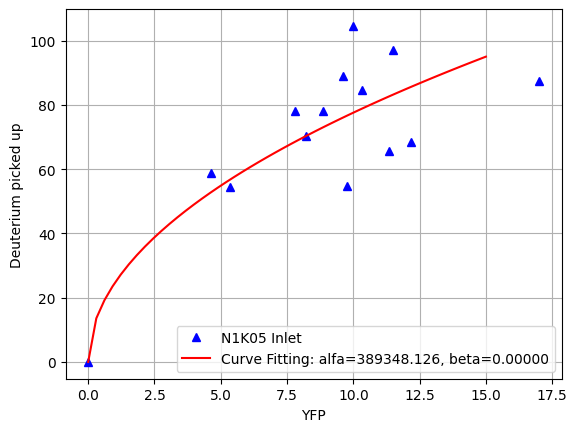

alfa_INLET: 389348.125841132
beta_INLET: 1.0121319471799258e-10
a_INLET: 50752.18844838412
b_INLET: 0.13035169577031128
end


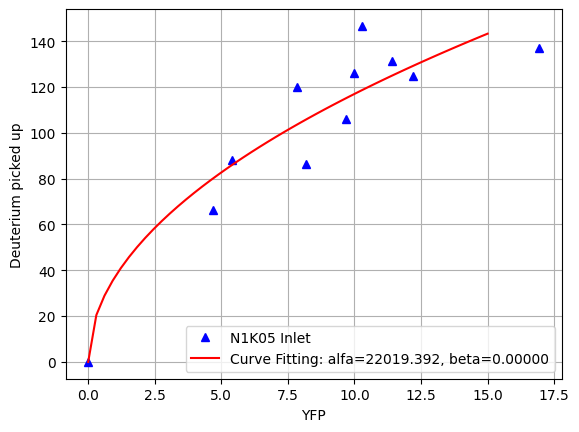

alfa_OUTLET: 22019.39230667178
beta_OUTLET: 2.6989610598756195e-09
a_OUTLET: 33653.33028835134
b_OUTLET: 1.528349639247516
end


np.float64(88.47243863255062)

In [107]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np
import math

from pathlib import Path
import pandas as pd

BASE_DIR = Path(r".\data\Masa de deuterio")  # ajustá si tu carpeta se llama distinto

inlet_path = BASE_DIR / "inlet.txt"
# según tu mensaje: "outet.txt" (con ese nombre). Igual dejo fallback por si era "outlet.txt"
outlet_path = BASE_DIR / "outet.txt"
if not outlet_path.exists():
    outlet_path = BASE_DIR / "outlet.txt"

def leer_txt_auto(path: Path) -> pd.DataFrame:
    # intenta autodetectar separador
        return pd.read_csv(path, sep="\t", decimal=",", engine="python", comment="#", encoding="utf-8-sig")


df_inlet  = leer_txt_auto(inlet_path)
df_outlet = leer_txt_auto(outlet_path)

print("INLET:", df_inlet.shape)
print(df_inlet.head())

print("\nOUTLET:", df_outlet.shape)
print(df_outlet.head())

#funcion de fiteo

# def func(t, alfa, beta, r=5.373, w=0.406, ro=6.490, long = 5.0):
#     return beta*r*w*ro*long * (alfa*np.sqrt(t)-np.log(1 + alfa*np.sqrt(t)))

#######################################
##### Fitting para el INLET de TP #####
#######################################

#Bruce Inlet
#xdata =[0.0,4.027,4.58,6.9,7.5,8.194,9.027,9.305,10.69,9.72,10.0,10.8,]
#ydata= [0.0,59.0,55.0,80.0,72.0,79.0,90.0,59.0,67.0,105.0,86.0,97.0]
#Bruce Inlet capped
xdata = pd.to_numeric(df_inlet["t [APP]"].astype(str).str.replace(",", ".", regex=False), errors="coerce").to_numpy()
ydata = pd.to_numeric(df_inlet["M [mg]"].astype(str).str.replace(",", ".", regex=False), errors="coerce").to_numpy()

# xdata =[0.0,4.027,4.58,6.9,7.5,8.194,9.027,9.305,10.69,9.72,10.0,10.8,]
# ydata= [0.0,59.0,55.0,80.0,72.0,79.0,90.0,59.0,67.0,105.0,86.0,97.0]

plt.plot(xdata, ydata, 'b^', label='N1K05 Inlet')
p0=[0.1,0.1]

# xdata debe ser numpy array numérico y con t>=0
tmax = float(np.max(xdata))
alpha_min = -1.0/np.sqrt(tmax) # margen


def func(t, alfa, beta, r=5.373, w=0.406, ro=6.490, long = 7):
    s = alfa*np.sqrt(t)
    return 1000 * 2 * math.pi * r * w * long * ro * beta * (s - np.log1p(s))   # mg

popt, pcov = curve_fit(
    func, xdata, ydata,
    p0=[0.1, 0.1],
    bounds=([alpha_min, 0.0], [np.inf, np.inf]),  # alfa >= alpha_min, beta >= 0
    method="trf",
    maxfev=20000
)

# popt, pcov = curve_fit(func, xdata, ydata, p0=p0,method='lm', maxfev=20000)
x_g_data = np.linspace(0,15)

alfa_inlet = popt[0]
beta_inlet = popt[1]

a_inlet = 2/(popt[0]*popt[1])
b_inlet = 2/(popt[0]**2*popt[1])

plt.plot(x_g_data, func(x_g_data, *popt), 'r-',label='Curve Fitting: alfa=%5.3f, beta=%5.5f' % tuple(popt))
plt.xlabel('YFP')
plt.ylabel('Deuterium picked up')
plt.legend()
plt.grid()
plt.show()
print('alfa_INLET: {}'.format(alfa_inlet))
print('beta_INLET: {}'.format(beta_inlet))
print('a_INLET: {}'.format((a_inlet)))
print('b_INLET: {}'.format(b_inlet))
print("end")


#######################################
##### Fitting para el OUTLET de TP #####
#######################################

#Bruce Inlet
#xdata =[0.0,4.027,4.58,6.9,7.5,8.194,9.027,9.305,10.69,9.72,10.0,10.8,]
#ydata= [0.0,59.0,55.0,80.0,72.0,79.0,90.0,59.0,67.0,105.0,86.0,97.0]
#Bruce Inlet capped
xdata = pd.to_numeric(df_outlet["t [APP]"].astype(str).str.replace(",", ".", regex=False), errors="coerce").to_numpy()
ydata = pd.to_numeric(df_outlet["M [mg]"].astype(str).str.replace(",", ".", regex=False), errors="coerce").to_numpy()

# xdata =[0.0,4.027,4.58,6.9,7.5,8.194,9.027,9.305,10.69,9.72,10.0,10.8,]
# ydata= [0.0,59.0,55.0,80.0,72.0,79.0,90.0,59.0,67.0,105.0,86.0,97.0]

plt.plot(xdata, ydata, 'b^', label='N1K05 Inlet')
p0=[0.1,0.1]

popt, pcov = curve_fit(
    func, xdata, ydata,
    p0=[0.1, 0.1],
    bounds=([0.0, 0.0], [np.inf, np.inf]),
    method="trf",
    maxfev=200000
)
x_g_data = np.linspace(0,15)

alfa_outlet = popt[0]
beta_outlet = popt[1]

a_outlet = 2/(popt[0]*popt[1])
b_outlet = 2/(popt[0]**2*popt[1])


plt.plot(x_g_data, func(x_g_data, *popt), 'r-',label='Curve Fitting: alfa=%5.3f, beta=%5.5f' % tuple(popt))
plt.xlabel('YFP')
plt.ylabel('Deuterium picked up')
plt.legend()
plt.grid()
plt.show()
print('alfa_OUTLET: {}'.format(alfa_outlet))
print('beta_OUTLET: {}'.format(beta_outlet))
print('a_OUTLET: {}'.format(a_outlet))
print('b_OUTLET: {}'.format(b_outlet))
print("end")

func(13, alfa_inlet, beta_inlet)



Pruebas con la formula de Temperaturas obtenidas con la formula original del RJDIM

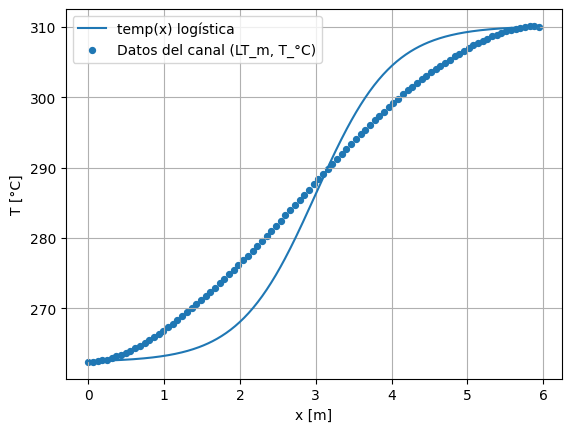

In [108]:
import numpy as np
import matplotlib.pyplot as plt

# --- tu función ---
def temp(x, Tmin=265, Tmax=305):
    return ((Tmax - Tmin) / (1 + np.exp(-(2*x - 6)))) + Tmin

# --- elegir el canal ---
canal = canales_dict["R-12"]   # cambiá por el que quieras

# --- extraer puntos del diccionario ---
x_pts = np.array(canal.get("LT_m", canal.get("L_m")), dtype=float)
T_pts = np.array(canal["T_°C"], dtype=float)

# ordenar por x (por prolijidad)
idx = np.argsort(x_pts)
x_pts, T_pts = x_pts[idx], T_pts[idx]

# --- generar curva de temp(x) en una grilla ---
x_min = float(np.nanmin(x_pts))
x_max = float(np.nanmax(x_pts))
x_grid = np.linspace(x_min, x_max, 400)
T_grid = temp(x_grid, Tmin=min(canal["T_°C"]), Tmax=max(canal["T_°C"]))

# --- plot ---
plt.figure()
plt.plot(x_grid, T_grid, label="temp(x) logística")
plt.scatter(x_pts, T_pts, s=18, label="Datos del canal (LT_m, T_°C)")
plt.xlabel("x [m]")
plt.ylabel("T [°C]")
plt.grid(True)
plt.legend()
plt.show()

Funciones necesarias para determinar valores de flujo y de temperatura por interpolacion

In [109]:
import numpy as np

try:
    from scipy.interpolate import PchipInterpolator
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False


def _prep_xy(x_list, y_list):
    """Convierte a arrays, limpia NaN, ordena"""
    x = np.asarray(x_list, dtype=float)
    y = np.asarray(y_list, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    idx = np.argsort(x)
    x, y = x[idx], y[idx]

    return x, y


def _interp(x_base, y_base, xq, method="pchip", extrapolate=False):
    xq = np.asarray(xq, dtype=float)

    if method == "pchip":
        if not _HAS_SCIPY:
            raise ImportError("No está disponible SciPy para PCHIP. Usá method='linear'.")
        f = PchipInterpolator(x_base, y_base, extrapolate=extrapolate)
        return f(xq)

    if method == "linear":
        # np.interp extrapola con extremos; si no querés, devolvemos NaN fuera de rango
        yq = np.interp(xq, x_base, y_base)
        if not extrapolate:
            yq = np.where((xq < x_base.min()) | (xq > x_base.max()), np.nan, yq)
        return yq

    raise ValueError("method debe ser 'pchip' o 'linear'.")


def interpolar_T_y_flujo(canal: dict, X, method="pchip", extrapolate=False):
    """
    Devuelve (T_interp, flujo_interp) evaluados en posiciones X.

    canal: dict del canal, con claves típicas:
      - 'T_°C' y 'LT_m' (o 'L_m')
      - 'flujo' y 'Lf_m*6' o 'Lf_m'
    X: escalar o array-like de posiciones (m)
    """
    # --- Temperatura ---
    xT, yT = _prep_xy(canal["LT_m"], canal["T_°C"])

    # --- Flujo ---
    xF_raw = canal["Lf_m"]
    xF, yF = _prep_xy(xF_raw, canal["flujo"])

    # --- Interpolar en X ---
    T_interp = _interp(xT, yT, X, method=method, extrapolate=extrapolate)
    flujo_interp = _interp(xF, yF, X, method=method, extrapolate=extrapolate)

    return T_interp, flujo_interp

In [110]:
import numpy as np

R = 8.314  # J/mol/K

def D_cap(t, B, m):
    return B * (t**m)

def Tc_from_intersection(t, A, n, Q, B, m):
    denom = np.log(B/A) + (m-n)*np.log(t)   # ojo: puede ser 0 -> singularidad
    return -Q/(R*denom) - 273.15            # °C

def D_piecewise(X, A, n, Q, B, m):
    t, T = X
    Tc = Tc_from_intersection(t, A, n, Q, B, m)
    D1 = A * (t**n) * np.exp(-Q/((T+273.15)))
    D2 = B * (t**m)
    return np.where(T < Tc, D1, D2)

def dDdt_piecewise(t, T, A, n, Q, B, m):
    """
    Retorna cg = dD/dt en [ug/g/año] (misma unidad de D por unidad de tiempo).
    t: escalar en años (o la unidad que uses consistentemente en el fit)
    T: array (nodos_x,1) en °C
    """
    Tc = Tc_from_intersection(t, A, n, Q, B, m)

    # Rama Arrhenius: D1 = A t^n exp(-Q/(R(T+273.15)))
    # => dD1/dt = A n t^(n-1) exp(...)
    exp_term = np.exp(-Q/(R*(T + 273.15)))
    dD1 = A * n * (t**(n-1.0)) * exp_term

    # Rama cap: D2 = B t^m => dD2/dt = B m t^(m-1)
    dD2 = B * m * (t**(m-1.0))

    return np.where(T < Tc, dD1, dD2)

In [111]:
def diferencias_piecewise(x0, A, n, Q, B, m, canal, time, ci, L):
    # --- geometría y masa total ---
    r_cm, w_cm, rho = 5.373, 0.406, 6.490
    masa_total_g = 2*np.pi*r_cm*w_cm*rho*(L*100.0)

    dx = 0.01
    r_num = 0.01

    # malla
    x = np.arange(0.0, L + dx, dx)
    nodos_x = len(x)

    # perfiles
    T_x, flujo_x = interpolar_T_y_flujo(canal, x, method="pchip", extrapolate=True)
    T_x = np.asarray(T_x, float).reshape(nodos_x, 1)  # °C

    # dt
    T_ref = 273.0 + 250.0
    D_ref = 31536000*(1.17e-7)*np.exp(-8030/(1.987*T_ref))/np.sqrt(2)
    dt = r_num * dx*dx / D_ref

    # r_local(x)
    D_local = 31536000*(1.17e-7)*np.exp(-8030/(1.987*(T_x + 273.0)))/np.sqrt(2)
    rr = (D_local * dt / (dx**2)).flatten()

    # matriz explícita
    K = np.zeros((nodos_x, nodos_x))
    np.fill_diagonal(K, 1 - 2*rr)
    K[1:, :-1] += np.diag(rr[1:])
    K[:-1, 1:] += np.diag(rr[:-1])
    K[0, :] = 0;   K[0, 0] = 1 - 2*rr[0];    K[0, 1] = 2*rr[0]
    K[-1, :] = 0;  K[-1, -1] = 1 - 2*rr[-1]; K[-1, -2] = 2*rr[-1]

    # estado
    Cvec = np.full((nodos_x, 1), ci, order="F")  # ug/g
    bvec = np.zeros((nodos_x, 1), order="F")

    # --- rolado (lo dejé como lo tenías; si querés lo apagamos durante el fit) ---
    alfa_inlet,  beta_inlet  = 389348.125841132,  1.0121319471799258e-10
    alfa_outlet, beta_outlet = 3.466338196905457, 2.170768488027475e-05

    L_roll = 0.07
    n_roll = int(round(L_roll/dx))
    m_roll_g = 2*np.pi*r_cm*w_cm*rho*(L_roll*100.0)

    def dMdt_mgyr(t_years, alpha, beta):
        s = alpha*np.sqrt(t_years)
        return 1000.0 * m_roll_g * beta * (alpha**2/2.0) / (1.0 + s)  # mg/año

    fac = 8760.0/10000.0 
    j = dt
    while j <= time:
        # --------- NUEVO cg (piecewise Arrhenius+cap) ----------
        t10 = j * fac             # j en años -> t en 10kHH
        cg = dDdt_piecewise(t10, T_x, A, n, Q, B, m)/(fac)   # ug/g/año
        bvec[:] = dt * cg                               # ug/g
        # ------------------------------------------------------

        # rolado inlet/outlet (ug/g/año)
        dMin_mgyr  = dMdt_mgyr(j, alfa_inlet,  beta_inlet)
        dMout_mgyr = dMdt_mgyr(j, alfa_outlet, beta_outlet)
        term_in  = (dMin_mgyr  / m_roll_g) * 1000.0     # ug/g/año
        term_out = (dMout_mgyr / m_roll_g) * 1000.0     # ug/g/año
        bvec[:n_roll]  += dt * term_in
        bvec[-n_roll:] += dt * term_out

        Cvec = K @ Cvec + bvec
        j += dt

    # devolver en x0
    x0 = np.asarray(x0, float)
    idx = np.searchsorted(x, x0, side="right")
    idx = np.clip(idx, 0, nodos_x-1)
    return Cvec[idx].flatten()

A,B,m = [1.27000299e+08 1.43200000e+00 1.04030000e+00]


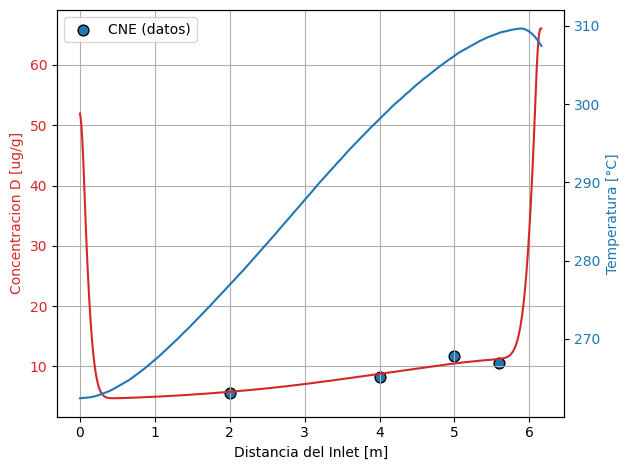

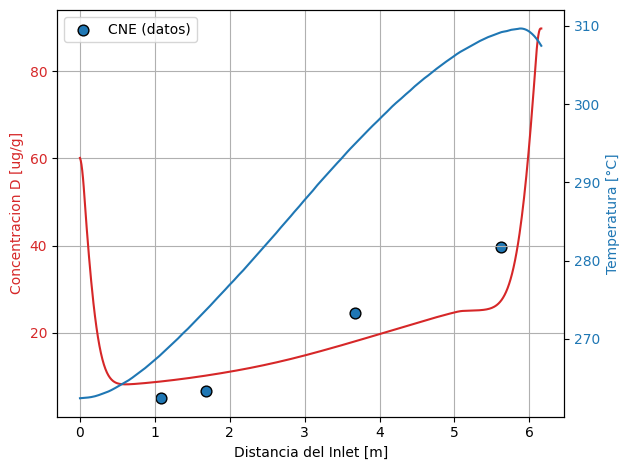

In [123]:
from scipy.optimize import curve_fit
import numpy as np

R = 8.314

#A_fix = np.exp(18.6597)   # del paper
n_fix = 1.1471
Q_fix = 89483.0           # J/mol

canal_data = canales_dict["K-12"]
L = 6.157
ci = 3.0
time = 42755/(24*365)  # años (lo que venís usando)
#time = 108150/(24*365)

# #P-17
# xCNE = np.array([2,4,5.0, 5.6])
# yCNE = np.array([5.62,8.21,11.8,10.55])

#K-12
xCNE = np.array([2,4,5.0, 5.6])
yCNE = np.array([5.62,8.21,11.8,10.55])

def dif_fit(x0, A, B, m):
    return diferencias_piecewise(x0, A, n_fix, Q_fix, B, m, canal_data, time, ci, L)

#p0 = [2.349e14, 2.1493, 20440, 1.432, 1.0403]  # iniciales razonables
#p0 = [1.432, 1.0403]
p0 = [np.exp(18.6597), 1.432, 1.0403]
#bounds = ([0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf])

popt, pcov = curve_fit(dif_fit, xCNE, yCNE, p0=p0, method="trf", maxfev=200000)
A_fit, B_fit, m_fit = popt
print("A,B,m =", popt)

dx = 0.01
x = np.arange(0.0, L + dx, dx)

y = diferencias_piecewise(
    x,
    A_fit, n_fix, Q_fix,
    B_fit, m_fit,
    canal_data,
    time,
    ci,
    L
)

fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Distancia del Inlet [m]')
ax1.set_ylabel('Concentracion D [ug/g]', color=color)
ax1.plot(x, y, color=color)
ax1.grid(True)
ax1.tick_params(axis='y', labelcolor=color)
ax1.scatter(
    xCNE, yCNE,
    s=60, marker="o",
    edgecolors="k",
    label="CNE (datos)"
)
ax1.legend(loc="best")

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

t, _ = interpolar_T_y_flujo(canal_data, x, method="pchip", extrapolate=True)

color = 'tab:blue'
ax2.set_ylabel('Temperatura [°C]', color=color)  # we already handled the x-label with ax1
ax2.plot(x, t, color=color)
ax2.tick_params(axis='y', labelcolor=color)

# ax3 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
# ax3.spines.right.set_position(("axes", 1.15))
# color = 'tab:green'
# ax3.set_ylabel('Fluencia [n/m2 s]', color=color)  # we already handled the x-label with ax1
# ax3.plot(x, flux, color=color)
# ax3.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()


time = 108150/(24*365)

xCNE = np.array([1.077,1.686,3.671, 5.619])
yCNE = np.array([5.04, 6.8, 24.5, 39.68])

y = diferencias_piecewise(
    x,
    A_fit, n_fix, Q_fix,
    B_fit, m_fit,
    canal_data,
    time,
    ci,
    L
)

fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Distancia del Inlet [m]')
ax1.set_ylabel('Concentracion D [ug/g]', color=color)
ax1.plot(x, y, color=color)
ax1.grid(True)
ax1.tick_params(axis='y', labelcolor=color)
ax1.scatter(
    xCNE, yCNE,
    s=60, marker="o",
    edgecolors="k",
    label="CNE (datos)"
)
ax1.legend(loc="best")

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

t, _ = interpolar_T_y_flujo(canal_data, x, method="pchip", extrapolate=True)

color = 'tab:blue'
ax2.set_ylabel('Temperatura [°C]', color=color)  # we already handled the x-label with ax1
ax2.plot(x, t, color=color)
ax2.tick_params(axis='y', labelcolor=color)

# ax3 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
# ax3.spines.right.set_position(("axes", 1.15))
# color = 'tab:green'
# ax3.set_ylabel('Fluencia [n/m2 s]', color=color)  # we already handled the x-label with ax1
# ax3.plot(x, flux, color=color)
# ax3.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()





Se realiza el fitteo de la ecuación de corrosión generalizada dada por Concentración=A*T+B*fl+C

rr.max = 0.02219451375300616 rr.min = 0.011958059475352785

=== Balance de masa (diagnóstico) ===
M_inj_in_mg (loop)   = 79.57066577017665
M_inj_out_mg (loop)  = 119.9921178172728
M_inj_cg_mg (loop)   = 356.032075523736
M_extra_final_mg     = 575.1819430964891
func(t) inlet [mg] = 86.21789681885629
func(t) out   [mg] = 130.00661363300313


ValueError: x and y must have same first dimension, but have shapes (615,) and (617,)

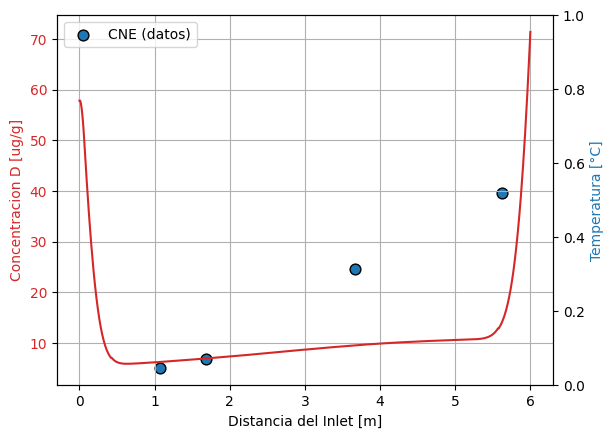

In [113]:
T=273 + 250 #K -Temperature inlet end
L=6.157 #m -largo del tubo
D=31536000*(1.17E-7)*np.exp(-8030/(1.987*T))/np.sqrt(2) #m2/años
r=0.2
dx=0.01 #m
dt=r*dx*dx/D #años
nodos_x=int(L/dx)
x = np.arange(0.0, L + dx, dx)
nodos_x=int(L/dx)


def dMdt(t, alpha, beta, r=5.373, w=0.406, ro=6.490, long=7):
    s = alpha*np.sqrt(t)
    return 1000 * 2 * math.pi * r * w * long * ro * beta * (alpha**2 / 2.0) / (1.0 + s)   # mg/año

def diferencias(x0, Acoef, Bcoef, Ccoef, canal, time, ci, L):
    # --- constantes / parámetros ---
    r_cm, w_cm, rho = 5.373, 0.406, 6.490                # m
    masa = 2*np.pi*r_cm*w_cm*rho*(L*100)  # g


    # a1 = 507.51091870029865
    # b1 = 0.0010770352102337513
    # a2 = 265.7924812384022
    # b2 = 76.68088361843232

    alfa_inlet, beta_inlet = 389348.125841132, 1.0121319471799258e-10
    alfa_outlet, beta_outlet = 22019.39230667178, 2.6989610598756195e-09

    dx = 0.01
    r  = 0.01

    # malla: usar arange para que el paso sea exactamente dx
    x = np.arange(0.0, L + dx, dx)
    nodos_x = len(x)

    # --- perfiles en TODA la malla ---
    T_x, flujo_x = interpolar_T_y_flujo(canal, x, method="pchip", extrapolate=True)
    flujo_x = flujo_x /1e12
    T_x = np.asarray(T_x, float).reshape(nodos_x, 1)
    flujo_x = np.asarray(flujo_x, float).reshape(nodos_x, 1)

    # fuente cg(x)
    cg = Acoef*T_x + Bcoef*flujo_x + Ccoef    # (nodos_x,1)

    # --- dt (con D_ref a una T de referencia, como vos hacías) ---
    T_ref = 273.0 + 250.0
    D_ref = 31536000*(1.17e-7)*np.exp(-8030/(1.987*T_ref))/np.sqrt(2)  # m2/año
    dt = r*dx*dx/D_ref

    # --- r_local(x) usando T(x) (OJO: sqrt(2) afuera) ---
    D_local = 31536000*(1.17e-7)*np.exp(-8030/(1.987*(T_x + 273.0)))/np.sqrt(2)  # m2/año
    rr = (D_local * dt / (dx**2)).flatten()  # (nodos_x,)

    print("rr.max =", rr.max(), "rr.min =", rr.min())


    # --- matriz explícita tridiagonal ---
    K = np.zeros((nodos_x, nodos_x))
    np.fill_diagonal(K, 1 - 2*rr)
    K[1:, :-1] += np.diag(rr[1:])
    K[:-1, 1:] += np.diag(rr[:-1])

    # contornos
    K[0, :] = 0;   K[0, 0] = 1 - 2*rr[0]; K[0,1] = 2*rr[0]
    K[-1, :] = 0;  K[-1, -1] = 1 - 2*rr[-1]; K[-1,-2] = 2*rr[-1]

    # --- iteración temporal ---
    Cvec = np.full((nodos_x, 1), ci, order="F")
    bvec = np.zeros((nodos_x, 1), order="F")

    L_roll = 0.07 #m
    n_roll = int(round(L_roll/dx))  # 7

    r_cm, w_cm, rho = 5.373, 0.406, 6.490
    m_roll = 2*np.pi*r_cm*w_cm*rho*(L_roll*100)  # g

    # --- masas nodales para balance (g) ---
    # Usa pesos trapezoidales para que sumen exactamente la masa total
    m_nodes = np.full(nodos_x, masa * dx / L)   # g por "celda/nodo" aprox
    m_nodes[0] *= 0.5
    m_nodes[-1] *= 0.5

    mask_in  = (x < L_roll)
    mask_out = (x > (L - L_roll))

    # masa discretizada en cada zona rolada (g) según la malla
    m_roll_in_disc = np.sum(m_nodes[:n_roll])
    m_roll_out_disc = np.sum(m_nodes[-n_roll:])

    # acumuladores de masa inyectada por rolado [mg]
    M_inj_in_mg = 0.0
    M_inj_out_mg = 0.0

    # (opcional) acumulador por cg para ver cuánto aporta el interior [mg]
    M_inj_cg_mg = 0.0


    j = dt
    while j <= time:
        term_in = (dMdt(j, alfa_inlet, beta_inlet) / m_roll) * 1000.0
        term_out = (dMdt(j, alfa_outlet, beta_outlet) / m_roll) * 1000.0

        # fuente base (cg) -> incremento de concentración [µg/g]
        bvec[:] = dt * cg

        # aporte rolado distribuido (incremento de concentración [µg/g])
        bvec[mask_in, 0]  += dt * term_in
        bvec[mask_out, 0] += dt * term_out

        # ---- DIAGNÓSTICO DE MASA INYECTADA ----
        # Masa inyectada por rolado en este paso [mg]
        # ΔM = (ΔC [µg/g]) * (masa [g]) / 1000
        dM_in_mg  = (dt * term_in)  * m_roll_in_disc  / 1000.0
        dM_out_mg = (dt * term_out) * m_roll_out_disc / 1000.0

        M_inj_in_mg  += dM_in_mg
        M_inj_out_mg += dM_out_mg

        # aporte del término cg en todo el tubo (puede ser + o -) [mg]
        dM_cg_mg = np.sum((dt * cg).flatten() * m_nodes) / 1000.0
        M_inj_cg_mg += dM_cg_mg
        # ---------------------------------------

        # tu chequeo (corregido a escalares)
        if (bvec[0,0] < 0) or (bvec[1,0] < 0) or (bvec[-1,0] < 0):
            print("break")

        Cvec = K @ Cvec + bvec
        j += dt


    # --- masa extra final en el tubo respecto a ci [mg] ---
    M_extra_final_mg = np.sum((Cvec.flatten() - ci) * m_nodes) / 1000.0

    print("\n=== Balance de masa (diagnóstico) ===")
    print("M_inj_in_mg (loop)   =", M_inj_in_mg)
    print("M_inj_out_mg (loop)  =", M_inj_out_mg)
    print("M_inj_cg_mg (loop)   =", M_inj_cg_mg)
    print("M_extra_final_mg     =", M_extra_final_mg)

    # Comparar contra fit de masa (si están disponibles)
    try:
        print("func(t) inlet [mg] =", func(time, alfa_inlet, beta_inlet))
        print("func(t) out   [mg] =", func(time, alfa_outlet, beta_outlet))
    except NameError:
        pass

    # --- devolver en x0 (lo que necesita curve_fit) ---
    x0 = np.asarray(x0, float)

    # Si tus x0 son posiciones reales desde inlet, NO deberías restar 1.
    # Si lo necesitás por tu convención, descomentá:
    # x0 = x0 - 1.0

    idx = np.searchsorted(x, x0, side="right")
    idx = np.clip(idx, 0, nodos_x-1)

    return Cvec[idx].flatten()


xCNE = np.array([1.077, 1.686, 3.671, 5.619])
yCNE = np.array([5.04,6.8,24.5,39.68])

# xCNE = np.array([2.002691954,	2.454912539,	2.786002577,	3.149394218,	3.528936352,	3.876177499,3.997308046,	4.457603877,	4.998654023])
# yCNE = np.array([1.485148529,	3.217821813,	4.455445587,	5.79207964,	7.277228169,	8.465345859,	8.910891173,	10.24752523,	11.485149])

p0=[0.2,0.4,0.1]

canal_data = canales_dict["P-17"]
time = 42755/(24*365)

def dif_fit(x0, Acoef, Bcoef, Ccoef):
    return diferencias(x0, Acoef, Bcoef, Ccoef, canal_data, time)

# popt, pcov = curve_fit(dif_fit, xCNE, yCNE, p0=p0,method='lm')

# popt, pcov = curve_fit(
#     dif_fit, xCNE, yCNE, p0=p0,
#     method="trf",
#     bounds=([0.0, 0.0, 0.0], [np.inf, np.inf, np.inf]),
#     maxfev=200000
# )

x = np.linspace(0,6,nodos_x)

time = 108150/(24*365)
#time =42755/(24*365)
ci = 3
                    
# 'Acoef' =
# 0.008877967570073296
# 'Bcoef' =
# 0.0011543470474459942
# 'Ccoef' =
# -2.132277545729512
y = diferencias(x,0.008877967570073296,0.0011543470474459942,-2.132277545729512,canal_data, time, ci, L)

# t, flux = interpolar_T_y_flujo(canal_data, x, method="pchip", extrapolate=True)

# y13 = diferencias(x, popt[0], popt[1], popt[2], canal_data, 13.0)
# y50 = diferencias(x, popt[0], popt[1], popt[2], canal_data, 50.0)

# print("max|y50-y13| =", np.max(np.abs(y50 - y13)))
# print("y13 extremos:", y13[0], y13[-1])
# print("y50 extremos:", y50[0], y50[-1])

fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Distancia del Inlet [m]')
ax1.set_ylabel('Concentracion D [ug/g]', color=color)
ax1.plot(x, y, color=color)
ax1.grid(True)
ax1.tick_params(axis='y', labelcolor=color)
ax1.scatter(
    xCNE, yCNE,
    s=60, marker="o",
    edgecolors="k",
    label="CNE (datos)"
)
ax1.legend(loc="best")

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Temperatura [°C]', color=color)  # we already handled the x-label with ax1
ax2.plot(x, t, color=color)
ax2.tick_params(axis='y', labelcolor=color)

ax3 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax3.spines.right.set_position(("axes", 1.15))
color = 'tab:green'
ax3.set_ylabel('Fluencia [n/m2 s]', color=color)  # we already handled the x-label with ax1
ax3.plot(x, flux, color=color)
ax3.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()


print("end")

In [ ]:
import numpy as np
from scipy.optimize import curve_fit

def softplus(x):
    return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0)

# Precalcular perfiles una sola vez (mucho mejor)
dx = 0.01
x_grid = np.arange(0.0, 6.0 + dx, dx)
T_grid, F_grid = interpolar_T_y_flujo(canal_data, x_grid, method="pchip", extrapolate=True)

T_grid = np.asarray(T_grid, float)
F_grid = np.asarray(F_grid, float) / 1e12  # tu normalización

Tmin = float(np.min(T_grid))
Fmin = float(np.min(F_grid))

# Wrapper “con restricciones”:
# u,v,z -> A,B,w -> C derivado -> llama a tu diferencias(A,B,C)
def dif_fit_restringido(x0, u, v, z):
    A = softplus(u)          # >0
    B = softplus(v)          # >0
    w = softplus(z) + 1e-9   # >0 margen mínimo
    C = w - A*Tmin - B*Fmin  # C puede ser negativo

    return diferencias(x0, A, B, C, canal_data)

# p0 en el espacio u,v,z (si querés arrancar cerca de A=0.2,B=0.4,w=0.1)
# softplus^-1 aproximada: log(exp(y)-1). Para y moderado sirve:
def inv_softplus(y):
    return np.log(np.expm1(y))

p0_uvz = [inv_softplus(0.2), inv_softplus(0.4), inv_softplus(0.1)]

popt_uvz, pcov = curve_fit(dif_fit_restringido, xCNE, yCNE, p0=p0_uvz, method="lm", maxfev=200000)

# Recuperar A,B,C finales
u,v,z = popt_uvz
A = softplus(u)
B = softplus(v)
w = softplus(z) + 1e-9
C = w - A*Tmin - B*Fmin

print("A,B,C =", A, B, C)

TypeError: diferencias() missing 2 required positional arguments: 'time' and 'ci'

In [ ]:
import numpy as np
from scipy.optimize import least_squares

# ---------- utilidades ----------
def softplus(x):
    # estable numéricamente
    return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0.0)

def inv_softplus(y):
    # y > 0
    y = np.asarray(y, float)
    eps = 1e-12
    y = np.maximum(y, eps)
    # inversa estable aproximada
    out = np.where(y > 30, y, np.log(np.expm1(y)))
    return out

def preparar_norm_cg(canal_data, L=6.0, dx=0.01):
    """
    Calcula medias/std y mínimos de T y flujo (ya escalado /1e12) sobre la misma malla que usa diferencias.
    """
    x_grid = np.arange(0.0, L + dx, dx)
    T_x, flujo_x = interpolar_T_y_flujo(canal_data, x_grid, method="pchip", extrapolate=True)

    T = np.asarray(T_x, float).flatten()
    F = np.asarray(flujo_x, float).flatten() / 1e12  # igual que en diferencias()

    mu_T, sd_T = T.mean(), T.std(ddof=0)
    mu_F, sd_F = F.mean(), F.std(ddof=0)

    # evitar divisiones por cero
    sd_T = sd_T if sd_T > 0 else 1.0
    sd_F = sd_F if sd_F > 0 else 1.0

    Tn = (T - mu_T)/sd_T
    Fn = (F - mu_F)/sd_F

    norm = {
        "x_grid": x_grid,
        "mu_T": mu_T, "sd_T": sd_T,
        "mu_F": mu_F, "sd_F": sd_F,
        "Tn_min": float(np.min(Tn)),
        "Fn_min": float(np.min(Fn)),
        "Tn_max": float(np.max(Tn)),
        "Fn_max": float(np.max(Fn)),
    }
    return norm

def uvz_a_coef_crudos(uvz, norm):
    """
    Reparametrización:
      A_n = softplus(u) > 0
      B_n = softplus(v) > 0
      w   = softplus(z) > 0
      C_n = w - A_n*Tn_min - B_n*Fn_min  -> garantiza cg_n >= w > 0
    Luego convierte a coeficientes crudos para usar en diferencias():
      cg = A_raw*T + B_raw*F + C_raw
    """
    u, v, z = uvz
    A_n = softplus(u)
    B_n = softplus(v)
    w   = softplus(z)

    C_n = w - A_n*norm["Tn_min"] - B_n*norm["Fn_min"]

    # cg_n = A_n*Tn + B_n*Fn + C_n
    # con Tn=(T-mu_T)/sd_T, Fn=(F-mu_F)/sd_F
    # => cg = A_raw*T + B_raw*F + C_raw
    A_raw = A_n / norm["sd_T"]
    B_raw = B_n / norm["sd_F"]
    C_raw = C_n - A_n*norm["mu_T"]/norm["sd_T"] - B_n*norm["mu_F"]/norm["sd_F"]

    return A_raw, B_raw, C_raw, {"A_n": A_n, "B_n": B_n, "w": w, "C_n": C_n}

In [ ]:
def ajustar_corrosion_generalizada(
    xCNE, yCNE, canal_data, time_fit,
    ci, L,
    x_pesos=None, y_sigma=None,
    uvz0=(0.5, 0.5, 0.2),
    loss="soft_l1", f_scale=0.5,
    verbose=1
):
    """
    Ajusta Acoef, Bcoef, Ccoef de corrosión generalizada usando least_squares,
    restando primero la curva base (A=B=C=0).

    Parámetros:
      - xCNE, yCNE: datos experimentales
      - canal_data: canales_dict["E-06"] por ejemplo
      - time_fit: tiempo del ajuste [años]
      - x_pesos: pesos por punto (opcional). Si None, todos 1.
      - y_sigma: sigma por punto (opcional). Si se da, usa 1/sigma como peso.
      - uvz0: semilla en espacio transformado (u,v,z)
    """

    xCNE = np.asarray(xCNE, float)
    yCNE = np.asarray(yCNE, float)

    # 1) Base solo rolado (sin corrosión generalizada)
    y_base = diferencias(xCNE, 0.0, 0.0, 0.0, canal_data, time_fit, ci, L)

    # 2) Objetivo residual
    y_obj_res = yCNE - y_base

    # 3) Normalización de T/F sobre la malla del canal
    norm = preparar_norm_cg(canal_data, L=6.0, dx=0.01)

    # 4) Pesos
    if x_pesos is None:
        w_pts = np.ones_like(yCNE, dtype=float)
    else:
        w_pts = np.asarray(x_pesos, float)

    if y_sigma is not None:
        y_sigma = np.asarray(y_sigma, float)
        w_pts = w_pts / np.maximum(y_sigma, 1e-12)

    # 5) Residuo para least_squares
    def residual_uvz(uvz):
        A_raw, B_raw, C_raw, aux = uvz_a_coef_crudos(uvz, norm)

        y_model = diferencias(xCNE, A_raw, B_raw, C_raw, canal_data, time_fit, ci, L)
        y_model_res = y_model - y_base

        # residuo pesado
        r = (y_model_res - y_obj_res) * w_pts
        return r

    # 6) Ajuste
    res = least_squares(
        residual_uvz,
        x0=np.asarray(uvz0, float),
        method="trf",
        loss=loss,       # "linear", "soft_l1", "huber"
        f_scale=f_scale,
        max_nfev=2000,
        verbose=2 if verbose else 0
    )

    # 7) Parámetros finales
    A_raw, B_raw, C_raw, aux = uvz_a_coef_crudos(res.x, norm)

    # 8) Covarianza aproximada (en uvz) + condición del Jacobiano
    m = len(res.fun)
    n = len(res.x)
    if res.jac is not None and m > 0:
        J = res.jac
        JTJ = J.T @ J
        dof = max(m - n, 1)
        s2 = np.sum(res.fun**2) / dof
        cov_uvz = s2 * np.linalg.pinv(JTJ)
        cond_JTJ = np.linalg.cond(JTJ)
    else:
        cov_uvz = None
        cond_JTJ = np.inf

    # 9) Resultado útil
    out = {
        "result_ls": res,
        "norm": norm,
        "y_base": y_base,
        "y_obj_res": y_obj_res,
        "Acoef": float(A_raw),
        "Bcoef": float(B_raw),
        "Ccoef": float(C_raw),
        "A_n": float(aux["A_n"]),
        "B_n": float(aux["B_n"]),
        "w_min_cg": float(aux["w"]),     # garantía de positividad en espacio normalizado
        "C_n": float(aux["C_n"]),
        "cov_uvz": cov_uvz,
        "cond_JTJ": float(cond_JTJ),
    }

    if verbose:
        print("\n=== Ajuste corrosión generalizada (residuo) ===")
        print("success:", res.success, "| status:", res.status)
        print("message:", res.message)
        print("Acoef =", out["Acoef"])
        print("Bcoef =", out["Bcoef"])
        print("Ccoef =", out["Ccoef"])
        print("A_n   =", out["A_n"])
        print("B_n   =", out["B_n"])
        print("w_min_cg (>=0) =", out["w_min_cg"])
        print("cond(JTJ) =", out["cond_JTJ"])

    return out

In [ ]:
xCNE = np.array([2, 4, 5, 5.6], dtype=float)
yCNE = np.array([5.62, 8.21, 11.8, 10.55], dtype=float)
ci = 3
L=6.157 #m -largo del tubo

canal_data = canales_dict["P-17"]

# Tiempo de ajuste (ejemplo: 42755 h en años)
time_fit = 42755/(24*365)


w_pts = np.array([1.0, 1.0, 1.0, 1])

aj = ajustar_corrosion_generalizada(
    xCNE, yCNE,
    canal_data=canal_data,
    time_fit=time_fit,
    ci = ci,
    L = L,
    x_pesos=w_pts,
    uvz0=(inv_softplus(0.5), inv_softplus(0.5), inv_softplus(0.2)),
    loss="soft_l1",
    f_scale=0.5,
    verbose=1
)

A_fit = aj["Acoef"]
B_fit = aj["Bcoef"]
C_fit = aj["Ccoef"]

print("salida")

rr.max = 0.02219451375300616 rr.min = 0.011958059475352785

=== Balance de masa (diagnóstico) ===
M_inj_in_mg (loop)   = 49.84892874351295
M_inj_out_mg (loop)  = 68.99774010335558
M_inj_cg_mg (loop)   = 0.0
M_extra_final_mg     = 119.16813705682533
func(t) inlet [mg] = 54.20947533024621
func(t) out   [mg] = 74.33609608742293
rr.max = 0.02219451375300616 rr.min = 0.011958059475352785

=== Balance de masa (diagnóstico) ===
M_inj_in_mg (loop)   = 49.84892874351295
M_inj_out_mg (loop)  = 68.99774010335558
M_inj_cg_mg (loop)   = 1654.6132221368384
M_extra_final_mg     = 1777.9726808049286
func(t) inlet [mg] = 54.20947533024621
func(t) out   [mg] = 74.33609608742293
rr.max = 0.02219451375300616 rr.min = 0.011958059475352785

=== Balance de masa (diagnóstico) ===
M_inj_in_mg (loop)   = 49.84892874351295
M_inj_out_mg (loop)  = 68.99774010335558
M_inj_cg_mg (loop)   = 1654.6132197471427
M_extra_final_mg     = 1777.972678415683
func(t) inlet [mg] = 54.20947533024621
func(t) out   [mg] = 74.33609